# 08: Fundamentos Visuais do PCA

Gráficos conceituais que ilustram variância, covariância, autovetores, transformações e o workflow do PCA.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Arc
import matplotlib.patches as mpatches

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f8f2'
plt.rcParams['font.size'] = 11

## 1. Variância Visual

Dispersão dos dados: baixa vs alta variância.

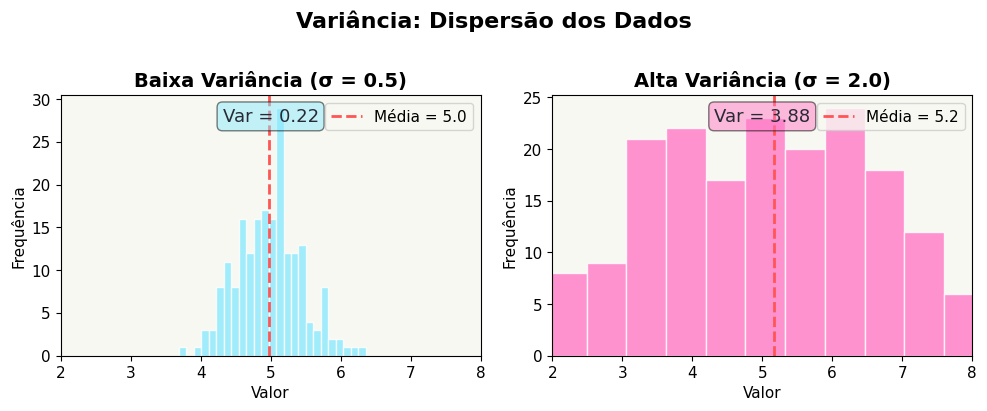

Salvo: ../graficos/variancia_visual.png


In [29]:
np.random.seed(42)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Baixa variância
x_low = np.random.normal(5, 0.5, 200)
axes[0].hist(x_low, bins=25, color='#8be9fd', edgecolor='white', alpha=0.8)
axes[0].axvline(x_low.mean(), color='#ff5555', linestyle='--', linewidth=2, label=f'Média = {x_low.mean():.1f}')
axes[0].set_title('Baixa Variância (σ = 0.5)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frequência')
axes[0].legend(fontsize=11)
axes[0].set_xlim(2, 8)
axes[0].text(0.5, 0.9, f'Var = {x_low.var():.2f}', transform=axes[0].transAxes,
             ha='center', fontsize=13, color='#282a36',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#8be9fd', alpha=0.5))

# Alta variância
x_high = np.random.normal(5, 2.0, 200)
axes[1].hist(x_high, bins=25, color='#ff79c6', edgecolor='white', alpha=0.8)
axes[1].axvline(x_high.mean(), color='#ff5555', linestyle='--', linewidth=2, label=f'Média = {x_high.mean():.1f}')
axes[1].set_title('Alta Variância (σ = 2.0)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Frequência')
axes[1].legend(fontsize=11)
axes[1].set_xlim(2, 8)
axes[1].text(0.5, 0.9, f'Var = {x_high.var():.2f}', transform=axes[1].transAxes,
             ha='center', fontsize=13, color='#282a36',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#ff79c6', alpha=0.5))

plt.suptitle('Variância: Dispersão dos Dados', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../graficos/variancia_visual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: ../graficos/variancia_visual.png')

## 2. Covariância Visual

Três padrões: positiva, zero, negativa.

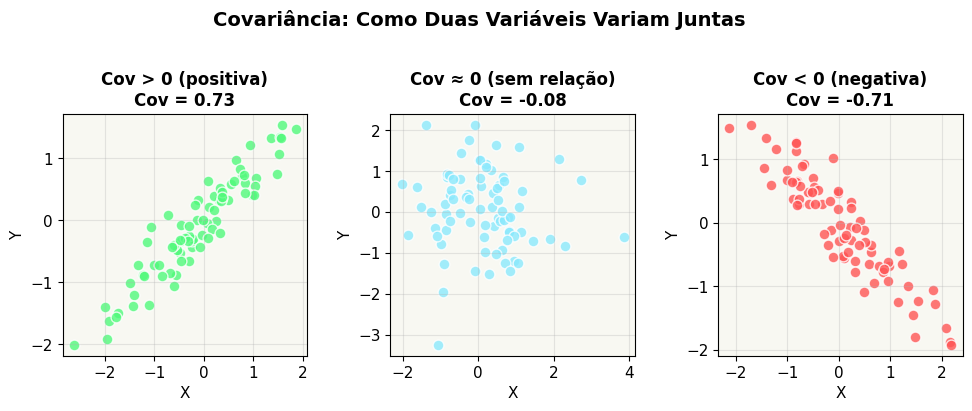

Salvo: ../graficos/covariancia_visual.png


In [30]:
np.random.seed(42)
n = 80

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

# Positiva
x1 = np.random.randn(n)
y1 = 0.8 * x1 + np.random.randn(n) * 0.3
axes[0].scatter(x1, y1, c='#50fa7b', edgecolors='white', s=60, alpha=0.8)
axes[0].set_title(f'Cov > 0 (positiva)\nCov = {np.cov(x1, y1)[0,1]:.2f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].grid(True, alpha=0.3)

# Zero
x2 = np.random.randn(n)
y2 = np.random.randn(n)
axes[1].scatter(x2, y2, c='#8be9fd', edgecolors='white', s=60, alpha=0.8)
axes[1].set_title(f'Cov ≈ 0 (sem relação)\nCov = {np.cov(x2, y2)[0,1]:.2f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].grid(True, alpha=0.3)

# Negativa
x3 = np.random.randn(n)
y3 = -0.8 * x3 + np.random.randn(n) * 0.3
axes[2].scatter(x3, y3, c='#ff5555', edgecolors='white', s=60, alpha=0.8)
axes[2].set_title(f'Cov < 0 (negativa)\nCov = {np.cov(x3, y3)[0,1]:.2f}', fontsize=12, fontweight='bold')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Covariância: Como Duas Variáveis Variam Juntas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../graficos/covariancia_visual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: ../graficos/covariancia_visual.png')

## 3. Matriz de Covariância — Heatmap

Heatmap de uma matriz de covariância 3x3 com variáveis correlacionadas.

/tmp/ipykernel_1870728/1353159567.py:9: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  data = np.random.multivariate_normal(mean, cov_true, n)


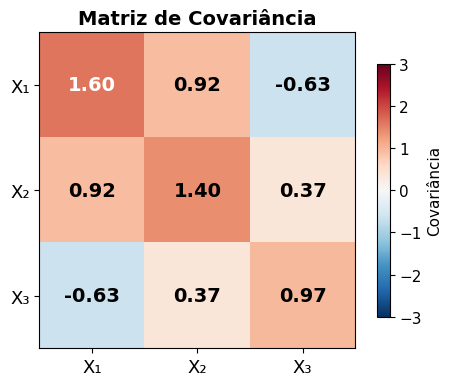

Salvo: ../graficos/matriz_covariancia_heatmap.png


In [27]:
np.random.seed(42)
n = 200

# Gerar dados com correlação
mean = [0, 0, 0]
cov_true = [[2.0, 1.2, -0.8],
            [1.2, 1.5,  0.3],
            [-0.8, 0.3, 1.0]]
data = np.random.multivariate_normal(mean, cov_true, n)

# Matriz de covariância empírica
cov_matrix = np.cov(data.T)
labels = ['X₁', 'X₂', 'X₃']

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cov_matrix, cmap='RdBu_r', vmin=-3, vmax=3)

for i in range(3):
    for j in range(3):
        color = 'white' if abs(cov_matrix[i, j]) > 1.5 else 'black'
        ax.text(j, i, f'{cov_matrix[i, j]:.2f}', ha='center', va='center',
                fontsize=14, fontweight='bold', color=color)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(labels, fontsize=13)
ax.set_yticklabels(labels, fontsize=13)
ax.set_title('Matriz de Covariância', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='Covariância')

plt.tight_layout()
plt.savefig('../graficos/matriz_covariancia_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: ../graficos/matriz_covariancia_heatmap.png')

## 4. Transformação de Vetor

Mostra como uma matriz M transforma um vetor v em v' (rotação + escala).

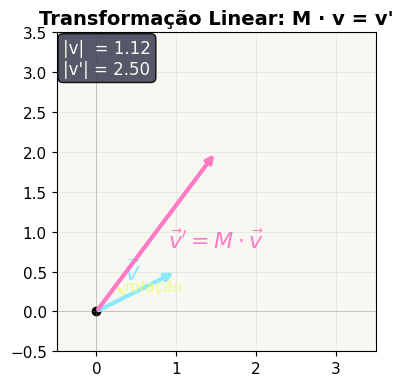

Salvo: ../graficos/transformacao_vetor.png


In [36]:
fig, ax = plt.subplots(figsize=(4, 4))

# Vetor original
v = np.array([1.0, 0.5])

# Matriz de transformação (rotação + escala)
theta = np.radians(40)
M = np.array([[2, -1],
              [1,  2]])
v_prime = M @ v

# Origem
ax.plot(0, 0, 'ko', markersize=6)

# Vetor original
ax.annotate('', xy=v, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#8be9fd', lw=3))
ax.text(v[0]*0.5 - 0.15, v[1]*0.5 + 0.15, r'$\vec{v}$', fontsize=18, color='#8be9fd', fontweight='bold')

# Vetor transformado
ax.annotate('', xy=v_prime, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#ff79c6', lw=3))
ax.text(v_prime[0]*0.5 + 0.15, v_prime[1]*0.5 - 0.2, r"$\vec{v}' = M \cdot \vec{v}$",
        fontsize=16, color='#ff79c6', fontweight='bold')

# Arco mostrando rotação
angle_v = np.degrees(np.arctan2(v[1], v[0]))
angle_vp = np.degrees(np.arctan2(v_prime[1], v_prime[0]))
arc = Arc((0, 0), 0.8, 0.8, angle=0, theta1=angle_v, theta2=angle_vp, color='#f1fa8c', lw=2)
ax.add_patch(arc)
ax.text(0.35, 0.25, 'rotação', fontsize=11, color='#f1fa8c', style='italic')

# Informação
info = f'|v|  = {np.linalg.norm(v):.2f}\n|v\'| = {np.linalg.norm(v_prime):.2f}'
ax.text(0.02, 0.98, info, transform=ax.transAxes, fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='#44475a', alpha=0.9), color='#f8f8f2')

ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-0.5, 3.5)
ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax.axvline(0, color='gray', lw=0.5, alpha=0.5)
ax.set_aspect('equal')
ax.set_title('Transformação Linear: M · v = v\'', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../graficos/transformacao_vetor.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: ../graficos/transformacao_vetor.png')

## 5. Autovetores Escalam (não rotacionam)

Mostra que Av = λv — o vetor fica na mesma direção, só muda o tamanho.

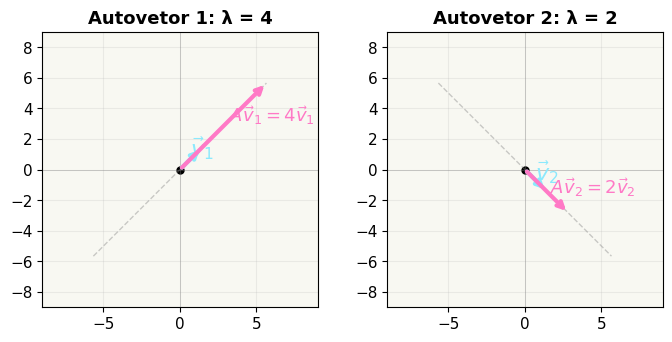

Salvo: autovetores_escalam.png


In [55]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(7, 4))

# Matriz simétrica (bonita + fácil de calcular)
A = np.array([[3, 1],
              [1, 3]])

# Autovalores e autovetores (definidos manualmente)
eigenvalues = np.array([4, 2])
eigenvectors = np.array([[1, 1],
                         [1, -1]])  # colunas = autovetores

for idx, (ax, ev, lam) in enumerate(zip(axes, eigenvectors.T, eigenvalues)):
    ax.plot(0, 0, 'ko', markersize=5)

    # Normalizar e escalar para visual consistente
    ev = ev / np.linalg.norm(ev)
    ev = ev * 2

    # Vetor original
    ax.annotate('', xy=ev, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#8be9fd', lw=3))
    ax.text(ev[0]*0.55 - 0.15, ev[1]*0.55 + 0.1,
            rf'$\vec{{v}}_{idx+1}$',
            fontsize=16, color='#8be9fd', fontweight='bold')

    # Vetor transformado
    Av = lam * ev
    ax.annotate('', xy=Av, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#ff79c6', lw=3))
    ax.text(Av[0]*0.55 + 0.1, Av[1]*0.55,
            rf'$A\vec{{v}}_{idx+1} = {lam}\vec{{v}}_{idx+1}$',
            fontsize=13, color='#ff79c6', fontweight='bold')

    # Linha tracejada (direção do autovetor)
    t = np.linspace(-1, 1, 100)
    ax.plot(ev[0]*t*4, ev[1]*t*4, '--', color='gray', alpha=0.4, lw=1)

    ax.set_xlim(-9, 9)
    ax.set_ylim(-9, 9)
    ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
    ax.axvline(0, color='gray', lw=0.5, alpha=0.5)
    ax.set_aspect('equal')
    ax.set_title(f'Autovetor {idx+1}: λ = {lam}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../graficos/autovetores_escalam.png', dpi=150, bbox_inches='tight')
plt.show()

print('Salvo: autovetores_escalam.png')

## 6. Autovetores Ortonormais

Dois vetores unitários perpendiculares (90°).

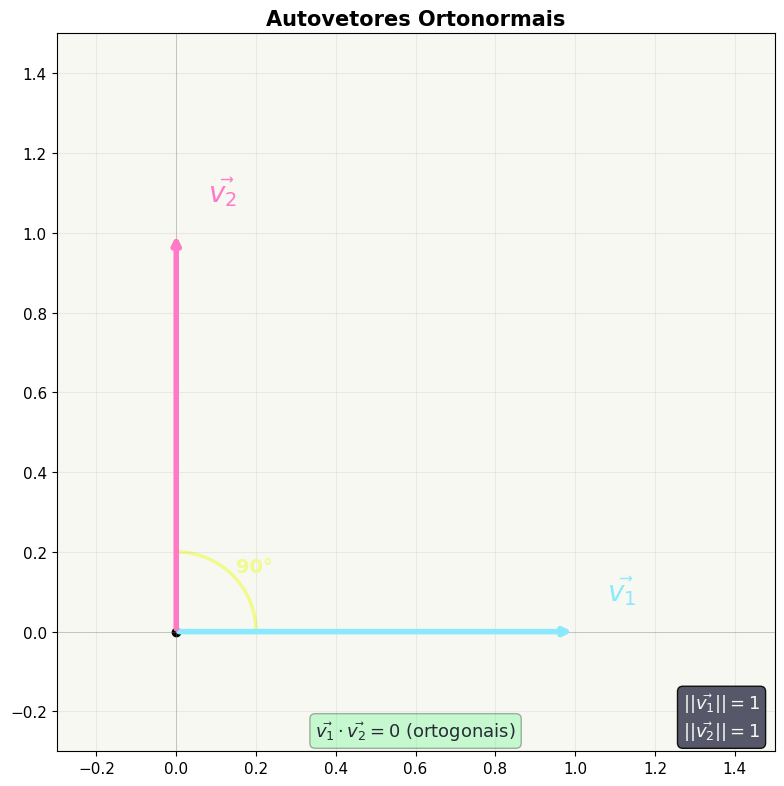

Salvo: ../graficos/autovetores_ortonormais.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

# Dois vetores ortonormais
v1 = np.array([1, 0])
v2 = np.array([0, 1])

ax.plot(0, 0, 'ko', markersize=6)

# v1
ax.annotate('', xy=v1, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#8be9fd', lw=4))
ax.text(v1[0] + 0.08, v1[1] + 0.08, r'$\vec{v_1}$', fontsize=20, color='#8be9fd', fontweight='bold')

# v2
ax.annotate('', xy=v2, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#ff79c6', lw=4))
ax.text(v2[0] + 0.08, v2[1] + 0.08, r'$\vec{v_2}$', fontsize=20, color='#ff79c6', fontweight='bold')

# Arco de 90°
arc = Arc((0, 0), 0.4, 0.4, angle=0, theta1=0, theta2=90, color='#f1fa8c', lw=2.5)
ax.add_patch(arc)
ax.text(0.15, 0.15, '90°', fontsize=14, color='#f1fa8c', fontweight='bold')

# Anotações
ax.text(0.98, 0.02, f'$||\\vec{{v_1}}|| = {np.linalg.norm(v1):.0f}$\n$||\\vec{{v_2}}|| = {np.linalg.norm(v2):.0f}$',
        transform=ax.transAxes, fontsize=13, ha='right',
        bbox=dict(boxstyle='round', facecolor='#44475a', alpha=0.9), color='#f8f8f2')

ax.text(0.5, 0.02, r'$\vec{v_1} \cdot \vec{v_2} = 0$ (ortogonais)',
        transform=ax.transAxes, fontsize=13, ha='center',
        bbox=dict(boxstyle='round', facecolor='#50fa7b', alpha=0.3), color='#282a36')

ax.set_xlim(-0.3, 1.5)
ax.set_ylim(-0.3, 1.5)
ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax.axvline(0, color='gray', lw=0.5, alpha=0.5)
ax.set_aspect('equal')
ax.set_title('Autovetores Ortonormais', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../graficos/autovetores_ortonormais.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: ../graficos/autovetores_ortonormais.png')

## 8. Workflow PCA em 4 Passos

Visualização do pipeline: dados → centralizar → covariância → projetar.

/tmp/ipykernel_1870728/1840661744.py:4: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal([3, 5], [[2.0, 1.5], [1.5, 1.0]], 60)


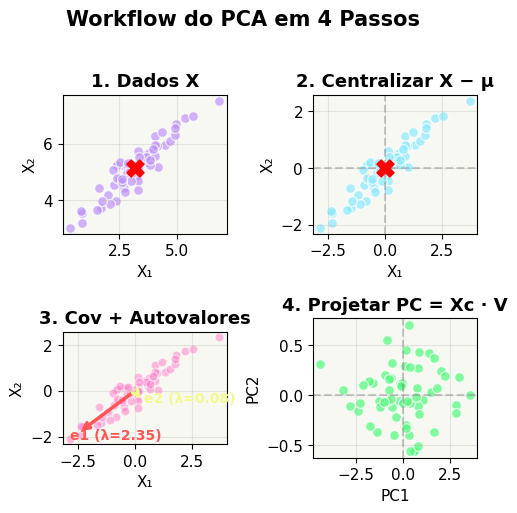

Salvo: ../graficos/pca_workflow_4passos.png


In [59]:
np.random.seed(42)

# Dados originais
X = np.random.multivariate_normal([3, 5], [[2.0, 1.5], [1.5, 1.0]], 60)
mu = X.mean(axis=0)
Xc = X - mu
cov = np.cov(Xc.T)
eigvals, eigvecs = np.linalg.eigh(cov)
idx = eigvals.argsort()[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]
PC = Xc @ eigvecs

fig, axes = plt.subplots(2, 2, figsize=(5, 5))
colors_step = ['#bd93f9', '#8be9fd', '#ff79c6', '#50fa7b']

# Passo 1: Dados
axes[0,0].scatter(X[:, 0], X[:, 1], c=colors_step[0], edgecolors='white', s=50, alpha=0.7)
axes[0,0].scatter(*mu, c='red', s=150, marker='X', zorder=5)
axes[0,0].set_title('1. Dados X', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('X₁')
axes[0,0].set_ylabel('X₂')
axes[0,0].grid(True, alpha=0.3)

# Passo 2: Centralizar
axes[0,1].scatter(Xc[:, 0], Xc[:, 1], c=colors_step[1], edgecolors='white', s=50, alpha=0.7)
axes[0,1].scatter(0, 0, c='red', s=150, marker='X', zorder=5)
axes[0,1].axhline(0, color='gray', ls='--', alpha=0.4)
axes[0,1].axvline(0, color='gray', ls='--', alpha=0.4)
axes[0,1].set_title('2. Centralizar X − μ', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('X₁')
axes[0,1].set_ylabel('X₂')
axes[0,1].grid(True, alpha=0.3)

# Passo 3: Covariância + autovetores
axes[1,0].scatter(Xc[:, 0], Xc[:, 1], c=colors_step[2], edgecolors='white', s=40, alpha=0.5)
for i, (color, lam) in enumerate(zip(['#ff5555', '#f1fa8c'], eigvals)):
    scale = np.sqrt(lam) * 2
    v = eigvecs[:, i] * scale
    axes[1,0].annotate('', xy=v, xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    axes[1,0].text(v[0]*1.15, v[1]*1.15, f'e{i+1} (λ={lam:.2f})', fontsize=10, color=color, fontweight='bold')
axes[1,0].set_title('3. Cov + Autovalores', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('X₁')
axes[1,0].set_ylabel('X₂')
axes[1,0].set_aspect('equal')
axes[1,0].grid(True, alpha=0.3)

# Passo 4: Projetar
axes[1,1].scatter(PC[:, 0], PC[:, 1], c=colors_step[3], edgecolors='white', s=50, alpha=0.7)
axes[1,1].axhline(0, color='gray', ls='--', alpha=0.4)
axes[1,1].axvline(0, color='gray', ls='--', alpha=0.4)
axes[1,1].set_title('4. Projetar PC = Xc · V', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('PC1')
axes[1,1].set_ylabel('PC2')
axes[1,1].grid(True, alpha=0.3)


plt.suptitle('Workflow do PCA em 4 Passos', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../graficos/pca_workflow_4passos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: ../graficos/pca_workflow_4passos.png')

## 9. Transformação Direta e Inversa

X → Z (PCA) → X̂ (reconstrução), mostrando perda ao usar poucos componentes.

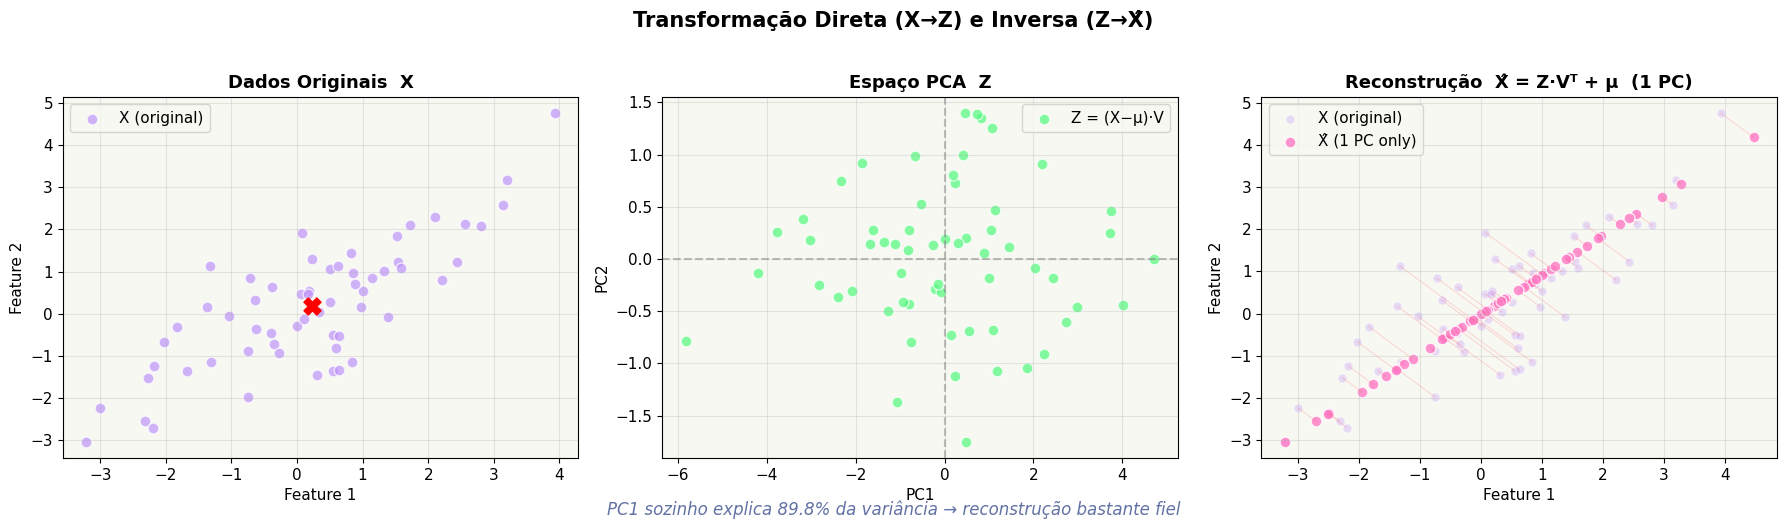

Salvo: ../graficos/transformacao_direta_inversa.png


In [22]:
np.random.seed(42)

# Dados 2D com correlação forte
X = np.random.multivariate_normal([0, 0], [[3, 2.5], [2.5, 3]], 60)
mu = X.mean(axis=0)
Xc = X - mu

eigvals, eigvecs = np.linalg.eigh(np.cov(Xc.T))
idx = eigvals.argsort()[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Projeção completa
Z = Xc @ eigvecs

# Reconstrução com 1 PC apenas
Z_k = Z.copy()
Z_k[:, 1] = 0  # zerar PC2
X_hat = Z_k @ eigvecs.T + mu

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Painel 1: Dados originais X
axes[0].scatter(X[:, 0], X[:, 1], c='#bd93f9', edgecolors='white', s=60, alpha=0.7, label='X (original)')
axes[0].scatter(*mu, c='red', s=150, marker='X', zorder=5)
axes[0].set_title('Dados Originais  X', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Painel 2: Espaço PCA (Z)
axes[1].scatter(Z[:, 0], Z[:, 1], c='#50fa7b', edgecolors='white', s=60, alpha=0.7, label='Z = (X−μ)·V')
axes[1].axhline(0, color='gray', ls='--', alpha=0.5)
axes[1].axvline(0, color='gray', ls='--', alpha=0.5)
axes[1].set_title('Espaço PCA  Z', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Painel 3: Reconstrução
axes[2].scatter(X[:, 0], X[:, 1], c='#bd93f9', edgecolors='white', s=40, alpha=0.3, label='X (original)')
axes[2].scatter(X_hat[:, 0], X_hat[:, 1], c='#ff79c6', edgecolors='white', s=60, alpha=0.8,
               label='X̂ (1 PC only)')
# Linhas conectando original → reconstruído
for i in range(len(X)):
    axes[2].plot([X[i, 0], X_hat[i, 0]], [X[i, 1], X_hat[i, 1]],
                 '-', color='#ff5555', alpha=0.2, lw=0.8)
axes[2].set_title('Reconstrução  X̂ = Z·Vᵀ + μ  (1 PC)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

var_1pc = eigvals[0] / eigvals.sum() * 100
fig.text(0.5, 0.01, f'PC1 sozinho explica {var_1pc:.1f}% da variância → reconstrução bastante fiel',
         ha='center', fontsize=12, color='#6272a4', style='italic')

plt.suptitle('Transformação Direta (X→Z) e Inversa (Z→X̂)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../graficos/transformacao_direta_inversa.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: ../graficos/transformacao_direta_inversa.png')

## 10. Variância Explicada por Componente

Gráfico de barras mostrando quanto cada componente contribui.

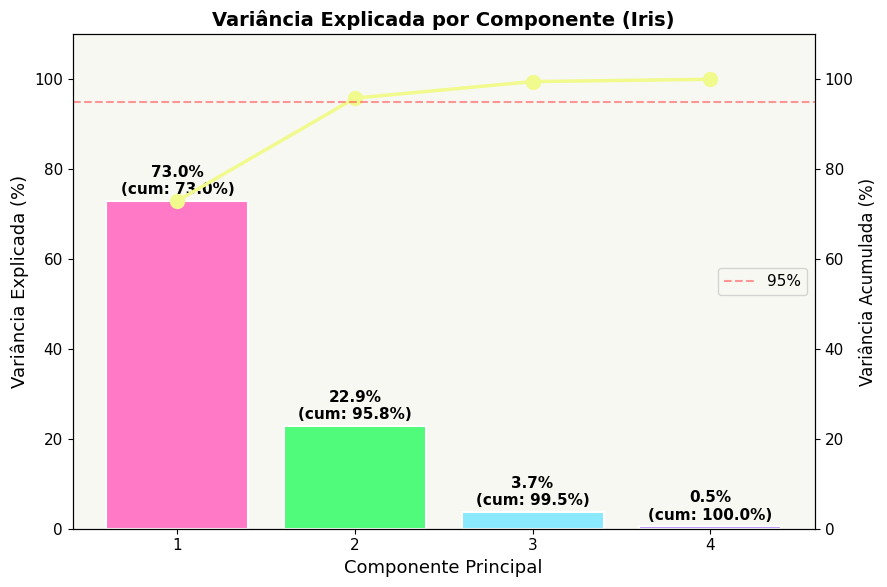

Salvo: ../graficos/variancia_explicada_componentes.png


In [23]:
# Usar dados Iris para variância realista
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()
X_scaled = StandardScaler().fit_transform(iris.data)
pca = PCA()
pca.fit(X_scaled)

var_ratio = pca.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)

fig, ax = plt.subplots(figsize=(9, 6))

bar_colors = ['#ff79c6', '#50fa7b', '#8be9fd', '#bd93f9']
bars = ax.bar(range(1, 5), var_ratio * 100, color=bar_colors, edgecolor='white', linewidth=1.5)

# Rótulos nas barras
for i, (bar, v, c) in enumerate(zip(bars, var_ratio, cum_var)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{v*100:.1f}%\n(cum: {c*100:.1f}%)',
            ha='center', fontsize=11, fontweight='bold')

# Linha cumulativa
ax2 = ax.twinx()
ax2.plot(range(1, 5), cum_var * 100, 'o-', color='#f1fa8c', linewidth=2.5, markersize=10)
ax2.axhline(95, color='#ff5555', ls='--', alpha=0.6, label='95%')
ax2.set_ylabel('Variância Acumulada (%)', fontsize=12)
ax2.set_ylim(0, 110)
ax2.legend(loc='center right')

ax.set_xlabel('Componente Principal', fontsize=13)
ax.set_ylabel('Variância Explicada (%)', fontsize=13)
ax.set_title('Variância Explicada por Componente (Iris)', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 5))
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('../graficos/variancia_explicada_componentes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: ../graficos/variancia_explicada_componentes.png')